In [21]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ---------- Configuration ----------
# Map every fine-grained question type to a high-level group.
# In the current dataset most marginal/conditional questions are "other_*";
# only a small fraction are labelled with a specific structural pattern.
QUESTION_GROUPS = {
    # Group 1: Causal Structure (easy)
    "causal_effect":  "Causal Structure",
    "all_causes_of":  "Causal Structure",
    "all_effects_of": "Causal Structure",

    # Group 2: Marginal Independence (medium)
    "other_marginal":       "Marginal Independence",
    "direct_marginal":      "Marginal Independence",
    "v_structure_marginal": "Marginal Independence",
    "chain_marginal":       "Marginal Independence",
    "fork_marginal":        "Marginal Independence",

    # Group 3: Conditional Independence (medium)
    "other_conditional":       "Conditional Independence",
    "v_structure_conditional": "Conditional Independence",
    "chain_conditional":       "Conditional Independence",
    "fork_conditional":        "Conditional Independence",
}

GROUP_ORDER = [
    "Causal Structure",
    "Marginal Independence",
    "Conditional Independence",
]

GROUP_COLORS = {
    "Causal Structure":         "#4CAF50",
    "Marginal Independence":    "#2196F3",
    "Conditional Independence": "#FF9800",
}

# List-answer question types (excluded from Yes/No bias analysis)
LIST_QUESTION_TYPES = {"all_causes_of", "all_effects_of"}

# ---------- Load data ----------
paths = ["../evaluations/eval_zero_shot_sub_opus_3_4.json"]

data = {}
for path in paths:
    with open(path, "r") as f:
        data.update(json.load(f))

scores   = data["scores"]
overall  = scores["overall"]
by_qtype = scores["by_question_type"]
by_diff  = scores["by_difficulty"]
by_n     = scores["by_n_nodes"]
set_q    = scores.get("set_questions", None)
evaluated = data.get("evaluated", [])

print(f"  Model : {data.get('model', '?')}")
print(f"  Source: {data.get('source', '?')}")
print(f"  Total : {overall['total']} questions, {overall['correct']} correct, accuracy={overall['accuracy']:.3f}")

  Model : us.anthropic.claude-opus-4-6-v1
  Source: ['results/zero_shot_sub_opus_3_4_easy.json', 'results/zero_shot_sub_opus_3_4_medium.json']
  Total : 360 questions, 197 correct, accuracy=0.547


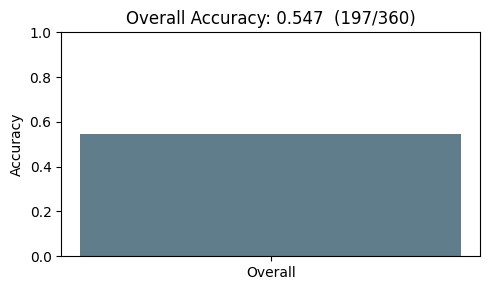

In [22]:
# ============================================================
# 1. Overall accuracy
# ============================================================
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["Overall"], [overall["accuracy"]], color="#607D8B")
ax.set_ylim(0, 1)
ax.set_title(f"Overall Accuracy: {overall['accuracy']:.3f}  ({overall['correct']}/{overall['total']})")
ax.set_ylabel("Accuracy")
fig.tight_layout()
plt.show()

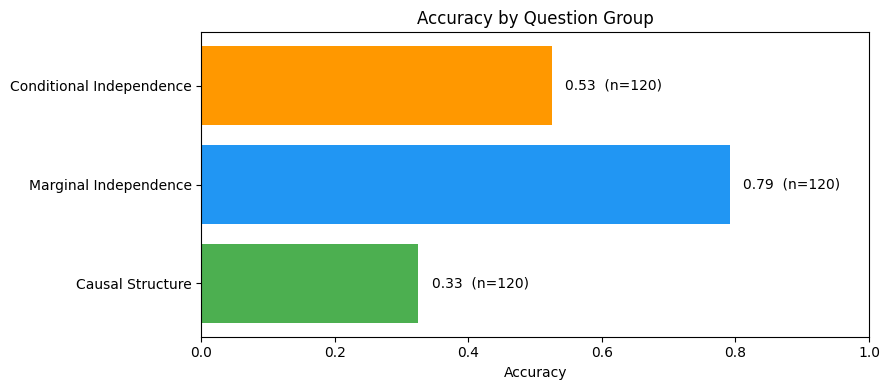

Group                         Correct / Total  Accuracy
----------------------------------------------------------
Causal Structure                   39 /   120     0.325
Marginal Independence              95 /   120     0.792
Conditional Independence           63 /   120     0.525
----------------------------------------------------------
OVERALL                           197 /   360     0.547


In [23]:
# ============================================================
# 2. Accuracy by GROUP (the main high-level view)
# ============================================================

# Aggregate correct/total per group
group_stats = {g: {"correct": 0, "total": 0} for g in GROUP_ORDER}

for qt, info in by_qtype.items():
    grp = QUESTION_GROUPS.get(qt)
    if grp is None:
        print(f"  Warning: question type '{qt}' not mapped to any group")
        continue
    group_stats[grp]["total"]   += info["total"]
    group_stats[grp]["correct"] += info["correct"]

grp_labels = [g for g in GROUP_ORDER if group_stats[g]["total"] > 0]
grp_acc    = [group_stats[g]["correct"] / group_stats[g]["total"] for g in grp_labels]
grp_n      = [group_stats[g]["total"] for g in grp_labels]
grp_colors = [GROUP_COLORS[g] for g in grp_labels]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(grp_labels, grp_acc, color=grp_colors)
ax.set_xlim(0, 1)
ax.set_xlabel("Accuracy")
ax.set_title("Accuracy by Question Group")

# Annotate with n
for bar, acc, n in zip(bars, grp_acc, grp_n):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{acc:.2f}  (n={n})", va="center", fontsize=10)

fig.tight_layout()
plt.show()

# Print table
print(f"{'Group':<28s}  {'Correct':>7s} / {'Total':>5s}  {'Accuracy':>8s}")
print("-" * 58)
for g in grp_labels:
    s = group_stats[g]
    acc = s["correct"] / s["total"]
    print(f"{g:<28s}  {s['correct']:>7d} / {s['total']:>5d}  {acc:>8.3f}")
print("-" * 58)
print(f"{'OVERALL':<28s}  {overall['correct']:>7d} / {overall['total']:>5d}  {overall['accuracy']:>8.3f}")

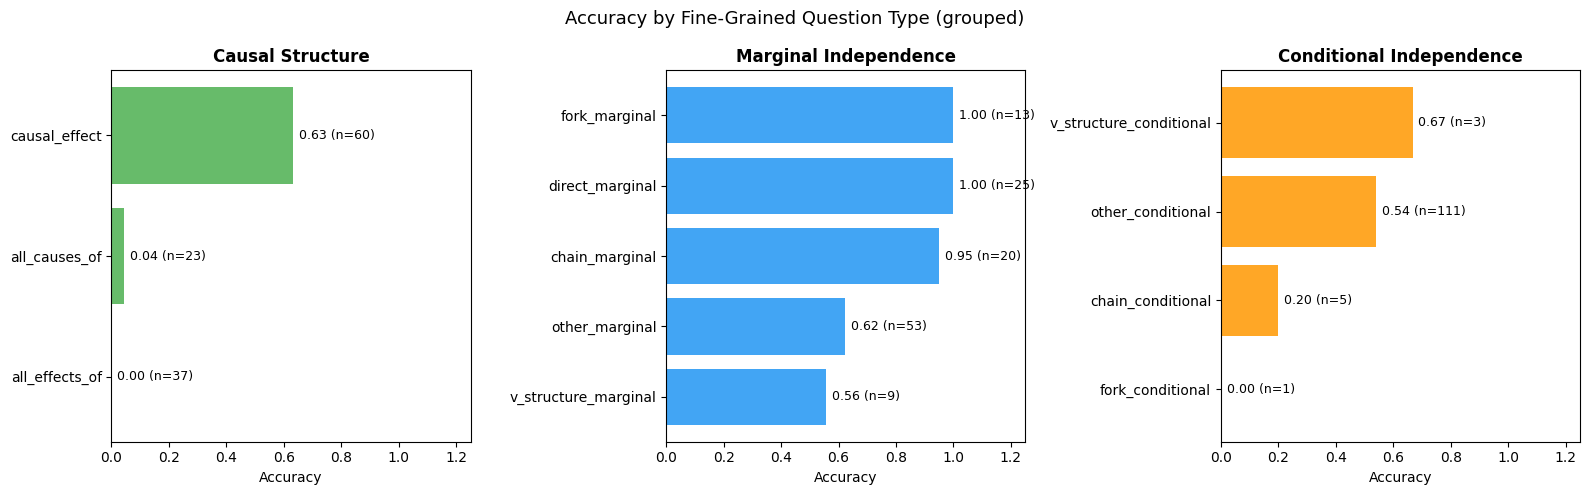

In [24]:
# ============================================================
# 3. Drill-down: fine-grained types within each group
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, grp in enumerate(GROUP_ORDER):
    ax = axes[idx]
    subtypes = [(qt, info) for qt, info in by_qtype.items()
                if QUESTION_GROUPS.get(qt) == grp and info["total"] > 0]
    if not subtypes:
        ax.set_visible(False)
        continue

    subtypes.sort(key=lambda x: x[1].get("accuracy", 0))
    labels = [qt for qt, _ in subtypes]
    accs   = [info.get("accuracy", 0) for _, info in subtypes]
    ns     = [info["total"] for _, info in subtypes]

    bars = ax.barh(labels, accs, color=GROUP_COLORS[grp], alpha=0.85)
    ax.set_xlim(0, 1.25)
    ax.set_title(grp, fontsize=12, fontweight="bold")
    ax.set_xlabel("Accuracy")

    for bar, acc, n in zip(bars, accs, ns):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f"{acc:.2f} (n={n})", va="center", fontsize=9)

fig.suptitle("Accuracy by Fine-Grained Question Type (grouped)", fontsize=13)
fig.tight_layout()
plt.show()

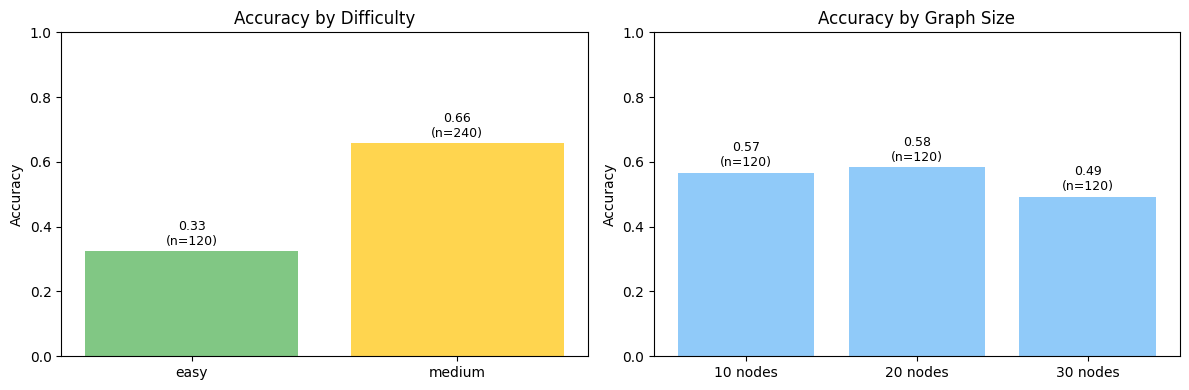

In [25]:
# ============================================================
# 4. Accuracy by difficulty & graph size (side by side)
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Difficulty — only easy/medium in this dataset
diff_order = ["easy", "medium"]
diff_labels = [d for d in diff_order if d in by_diff]
diff_acc = [by_diff[d]["accuracy"] for d in diff_labels]
diff_n   = [by_diff[d]["total"] for d in diff_labels]

bars1 = ax1.bar(diff_labels, diff_acc, color=["#81C784", "#FFD54F"])
ax1.set_ylim(0, 1)
ax1.set_title("Accuracy by Difficulty")
ax1.set_ylabel("Accuracy")
for bar, acc, n in zip(bars1, diff_acc, diff_n):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{acc:.2f}\n(n={n})", ha="center", fontsize=9)

# Graph size
n_labels = sorted(by_n.keys(), key=lambda x: int(x))
n_acc = [by_n[k]["accuracy"] for k in n_labels]
n_n   = [by_n[k]["total"] for k in n_labels]

bars2 = ax2.bar([f"{k} nodes" for k in n_labels], n_acc, color="#90CAF9")
ax2.set_ylim(0, 1)
ax2.set_title("Accuracy by Graph Size")
ax2.set_ylabel("Accuracy")
for bar, acc, n in zip(bars2, n_acc, n_n):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{acc:.2f}\n(n={n})", ha="center", fontsize=9)

fig.tight_layout()
plt.show()

Answer Bias Analysis (Yes/No questions only)
  Ground truth:  Yes=145 (48.3%),  No=155 (51.7%)
  Predictions:   Yes=123 (41.0%),  No=115 (38.3%),  Other=62

  When model says Yes: 92/123 correct (74.8%)
  When model says No:  91/115 correct (79.1%)


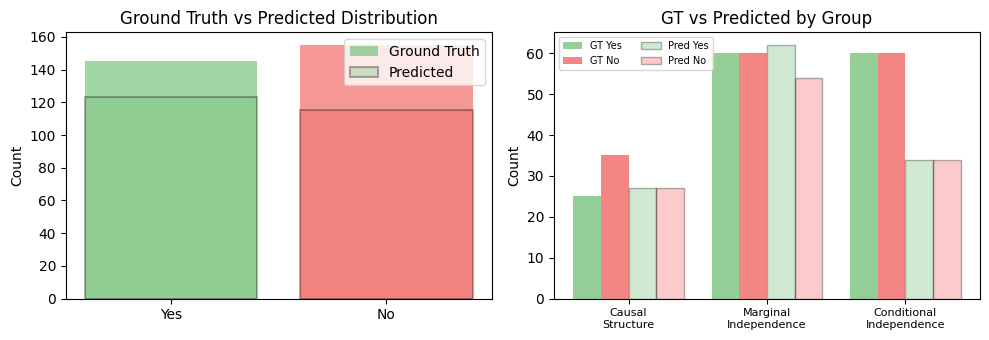

In [26]:
# ============================================================
# 5. Answer-bias check: does the model default to Yes or No?
# ============================================================

# Only Yes/No questions (exclude list-answer types)
yes_no_types = {qt for qt in QUESTION_GROUPS if qt not in LIST_QUESTION_TYPES}

gt_yes, gt_no = 0, 0
pred_yes, pred_no, pred_other = 0, 0, 0
correct_yes, correct_no = 0, 0

for item in evaluated:
    if item["question_type"] not in yes_no_types:
        continue
    gt = item["ground_truth"]
    pred = item["eval"].get("answer_parsed", item.get("extracted_answer", ""))

    if gt == "Yes":
        gt_yes += 1
    else:
        gt_no += 1

    if pred == "Yes":
        pred_yes += 1
        if gt == "Yes":
            correct_yes += 1
    elif pred == "No":
        pred_no += 1
        if gt == "No":
            correct_no += 1
    else:
        pred_other += 1

total_yn = gt_yes + gt_no

print("Answer Bias Analysis (Yes/No questions only)")
print("=" * 55)
print(f"  Ground truth:  Yes={gt_yes} ({gt_yes/total_yn:.1%}),  No={gt_no} ({gt_no/total_yn:.1%})")
print(f"  Predictions:   Yes={pred_yes} ({pred_yes/total_yn:.1%}),  No={pred_no} ({pred_no/total_yn:.1%}),  Other={pred_other}")
print()
if pred_yes > 0:
    print(f"  When model says Yes: {correct_yes}/{pred_yes} correct ({correct_yes/pred_yes:.1%})")
if pred_no > 0:
    print(f"  When model says No:  {correct_no}/{pred_no} correct ({correct_no/pred_no:.1%})")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

ax1.bar(["Yes", "No"], [gt_yes, gt_no], color=["#66BB6A", "#EF5350"], alpha=0.6, label="Ground Truth")
ax1.bar(["Yes", "No"], [pred_yes, pred_no], color=["#66BB6A", "#EF5350"], alpha=0.3, edgecolor="black", linewidth=1.5, label="Predicted")
ax1.set_title("Ground Truth vs Predicted Distribution")
ax1.set_ylabel("Count")
ax1.legend()

# Per-group breakdown
group_bias = defaultdict(lambda: {"gt_yes": 0, "gt_no": 0, "pred_yes": 0, "pred_no": 0})
for item in evaluated:
    qt = item["question_type"]
    if qt not in yes_no_types:
        continue
    grp = QUESTION_GROUPS.get(qt, "?")
    gt = item["ground_truth"]
    pred = item["eval"].get("answer_parsed", item.get("extracted_answer", ""))
    if gt == "Yes":
        group_bias[grp]["gt_yes"] += 1
    else:
        group_bias[grp]["gt_no"] += 1
    if pred == "Yes":
        group_bias[grp]["pred_yes"] += 1
    elif pred == "No":
        group_bias[grp]["pred_no"] += 1

grps = [g for g in GROUP_ORDER if g in group_bias]
x = np.arange(len(grps))
w = 0.2
ax2.bar(x - w*1.5, [group_bias[g]["gt_yes"] for g in grps], w, label="GT Yes", color="#66BB6A", alpha=0.7)
ax2.bar(x - w*0.5, [group_bias[g]["gt_no"] for g in grps],  w, label="GT No",  color="#EF5350", alpha=0.7)
ax2.bar(x + w*0.5, [group_bias[g]["pred_yes"] for g in grps], w, label="Pred Yes", color="#66BB6A", alpha=0.3, edgecolor="black")
ax2.bar(x + w*1.5, [group_bias[g]["pred_no"] for g in grps],  w, label="Pred No",  color="#EF5350", alpha=0.3, edgecolor="black")
ax2.set_xticks(x)
ax2.set_xticklabels([g.replace(" ", "\n") for g in grps], fontsize=8)
ax2.set_title("GT vs Predicted by Group")
ax2.set_ylabel("Count")
ax2.legend(fontsize=7, ncol=2)

fig.tight_layout()
plt.show()

Set/List Question Metrics
  Count:     60
  Precision: 0.297
  Recall:    0.146
  F1:        0.159


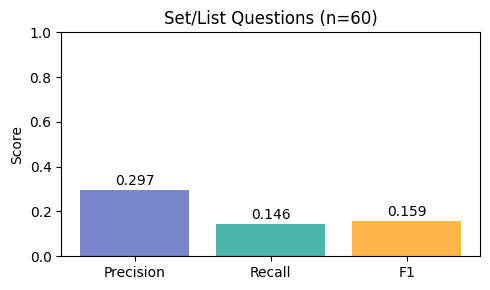

In [27]:
# ============================================================
# 6. Set/List question metrics (if present)
# ============================================================

if set_q and set_q.get("count", 0) > 0:
    print("Set/List Question Metrics")
    print("=" * 40)
    print(f"  Count:     {set_q['count']}")
    print(f"  Precision: {set_q['avg_precision']:.3f}")
    print(f"  Recall:    {set_q['avg_recall']:.3f}")
    print(f"  F1:        {set_q['avg_f1']:.3f}")

    fig, ax = plt.subplots(figsize=(5, 3))
    metrics = ["Precision", "Recall", "F1"]
    vals = [set_q["avg_precision"], set_q["avg_recall"], set_q["avg_f1"]]
    bars = ax.bar(metrics, vals, color=["#7986CB", "#4DB6AC", "#FFB74D"])
    ax.set_ylim(0, 1)
    ax.set_title(f"Set/List Questions (n={set_q['count']})")
    ax.set_ylabel("Score")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{v:.3f}", ha="center", fontsize=10)
    fig.tight_layout()
    plt.show()
else:
    print("No set/list question metrics available.")

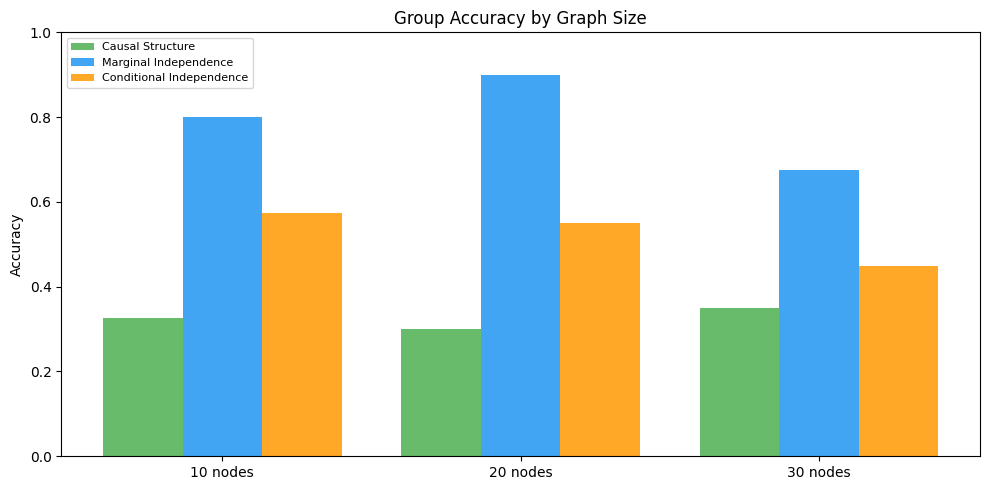

Group                          10 nodes   20 nodes   30 nodes
-------------------------------------------------------------
Causal Structure               0.33 (40)   0.30 (40)   0.35 (40)
Marginal Independence          0.80 (40)   0.90 (40)   0.68 (40)
Conditional Independence       0.57 (40)   0.55 (40)   0.45 (40)


In [28]:
# ============================================================
# 7. Group accuracy by graph size (interaction analysis)
# ============================================================

# Build per-(group, n_nodes) stats from evaluated items
gn_stats = defaultdict(lambda: {"correct": 0, "total": 0})
for item in evaluated:
    grp = QUESTION_GROUPS.get(item["question_type"])
    if grp is None:
        continue
    n = str(item["n_nodes"])
    gn_stats[(grp, n)]["total"] += 1
    if item["eval"]["correct"]:
        gn_stats[(grp, n)]["correct"] += 1

n_sizes = sorted({k[1] for k in gn_stats.keys()}, key=int)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(n_sizes))
w = 0.8 / len(GROUP_ORDER)

for i, grp in enumerate(GROUP_ORDER):
    accs = []
    for n in n_sizes:
        s = gn_stats.get((grp, n), {"correct": 0, "total": 0})
        accs.append(s["correct"] / s["total"] if s["total"] > 0 else 0)
    bars = ax.bar(x + i * w, accs, w, label=grp, color=GROUP_COLORS[grp], alpha=0.85)

ax.set_xticks(x + w * (len(GROUP_ORDER) - 1) / 2)
ax.set_xticklabels([f"{n} nodes" for n in n_sizes])
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("Group Accuracy by Graph Size")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

# Print table
print(f"{'Group':<28s}", end="")
for n in n_sizes:
    print(f"  {n:>3s} nodes", end="")
print()
print("-" * (28 + 11 * len(n_sizes)))
for grp in GROUP_ORDER:
    print(f"{grp:<28s}", end="")
    for n in n_sizes:
        s = gn_stats.get((grp, n), {"correct": 0, "total": 0})
        if s["total"] > 0:
            acc = s["correct"] / s["total"]
            print(f"  {acc:>5.2f} ({s['total']:>2d})", end="")
        else:
            print(f"       ---", end="")
    print()